In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [28]:
df_train = pd.read_csv("../data_train_frequency.csv")
df_train.drop(columns=["Unnamed: 0"],inplace=True)
df_train

,1,2,3,4,5,6,7,8,9,10,...,204,205,206,207,208,209,210,211,212,213
0,0.0,10.0,950.000000,1074.0,274.986868,782.0,-0.319753,-1.432466,325.821586,1.000000,...,1.000000,172.000000,10.000000,9.000000,252.222222,10656.395062,87.777778,10339.061728,135.800000,4315.560000
1,0.0,17.0,574.500000,582.0,104.913059,378.0,0.158313,-0.696295,336.569414,1.000000,...,0.882353,-15.000000,15.000000,4.000000,158.000000,3944.000000,73.000000,6555.000000,-1.066667,697.528889
2,3.0,16.0,593.600000,594.0,4.687572,18.0,0.396421,-0.312612,94.909877,1.000000,...,1.000000,-4.000000,16.000000,15.000000,122.400000,2058.773333,12.533333,1360.782222,95.500000,68.750000
3,3.0,23.0,420.090909,420.0,3.591772,12.0,-0.021014,-0.856142,254.059787,0.826087,...,0.739130,-9.000000,6.000000,4.000000,40.666667,1120.888889,5.333333,1504.888889,12.000000,1464.000000
4,1.0,9.0,1068.750000,1075.0,25.118469,76.0,-0.276816,-1.271399,461.130814,1.000000,...,1.000000,2.000000,9.000000,8.000000,122.000000,671.000000,19.750000,569.437500,136.444444,43.358025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,3.0,16.0,615.733333,596.0,51.114860,152.0,2.153820,2.645687,365.256750,1.000000,...,0.003757,0.022262,0.003757,0.003757,0.044242,0.044242,0.043021,0.043021,0.037385,0.037385
8512,1.0,9.0,1091.500000,1093.0,5.894913,18.0,-0.311206,-1.184514,358.414529,1.000000,...,0.888889,-3.000000,9.000000,8.000000,81.428571,1294.530612,-40.000000,1746.285714,155.333333,4722.666667
8513,2.0,15.0,654.428571,648.0,107.653355,458.0,0.475616,0.784000,180.045117,1.000000,...,1.000000,-4.000000,15.000000,14.000000,77.142857,2213.551020,-1.714286,2686.204082,104.000000,3602.666667
8514,1.0,9.0,1075.000000,1083.0,24.535688,66.0,-0.263431,-1.567800,251.455499,1.000000,...,1.000000,14.000000,9.000000,8.000000,101.142857,4933.551020,-10.750000,7259.937500,88.222222,202.172840


In [29]:
x_train = df_train.iloc[:,1:].values
y_train = df_train.iloc[:,0].values

In [30]:
scale = MinMaxScaler()
x_train = scale.fit_transform(x_train)

In [31]:
pca = PCA(n_components=0.99)
x_train = pca.fit_transform(x_train)

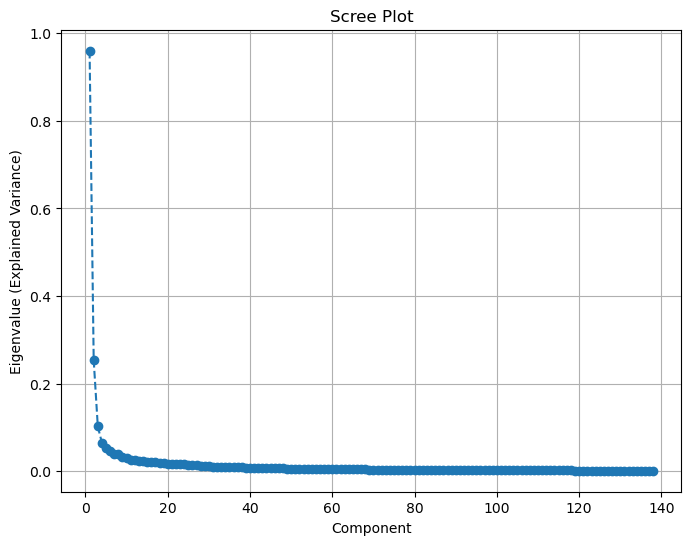

In [32]:
# Tính toán các giá trị riêng (explained variance)
explained_variance = pca.explained_variance_

# Vẽ Scree Plot
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.grid(True)
plt.show()

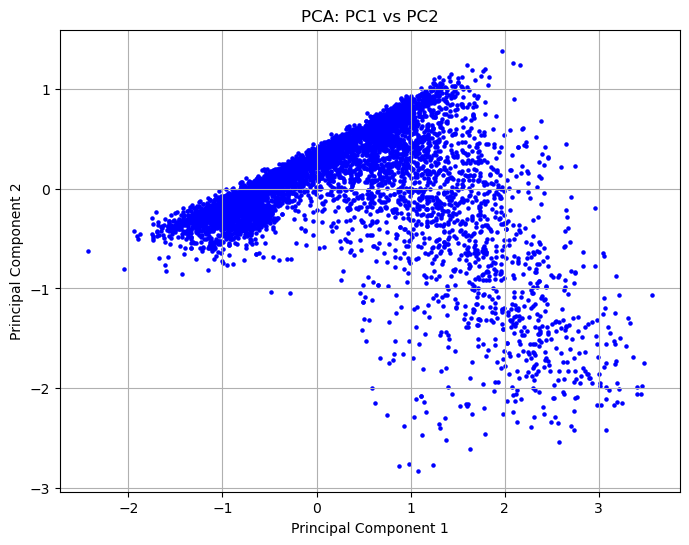

In [20]:
# Áp dụng PCA để giảm chiều xuống còn 2
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_train)

# Tạo DataFrame với kết quả PCA
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

# Vẽ biểu đồ scatter 2D
plt.figure(figsize=(8, 6))
plt.scatter(x='PC1', y='PC2', data=pca_df, color='blue', s=5)
plt.title('PCA: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


Phân tích biểu đồ:
Trục X (PC1): Đây là thành phần chính đầu tiên (PC1), nó thể hiện phương sai lớn nhất trong dữ liệu. Đối với biểu đồ này, giá trị của PC1 dao động từ khoảng -2 đến 3. Nó đại diện cho chiều dữ liệu có sự biến động lớn nhất.

Trục Y (PC2): Đây là thành phần chính thứ hai (PC2), thể hiện phương sai thứ hai lớn nhất trong dữ liệu. Các giá trị của PC2 dao động trong khoảng từ -3 đến 1.

Đặc điểm của dữ liệu:

Các điểm dữ liệu phân bố theo hình dạng nghiêng, với phần lớn dữ liệu nằm ở phía bên phải của biểu đồ. Điều này chỉ ra rằng dữ liệu có sự phân bố không đồng đều, và một phần lớn của dữ liệu có sự tương quan mạnh mẽ với PC1.

Phân bố dọc theo đường chéo, với các điểm dữ liệu ở góc trên bên trái của biểu đồ có giá trị PC1 âm và giá trị PC2 dương. Điều này cho thấy có thể tồn tại một nhóm đặc biệt hoặc một cấu trúc trong dữ liệu được nhóm lại gần nhau.

Sự phân bố các điểm từ trên xuống dưới và từ trái sang phải có thể chỉ ra rằng có một số nhóm trong dữ liệu, và PCA đã giảm chiều tốt để làm rõ sự phân tách giữa các nhóm này.

Khả năng phát hiện nhóm:

Mặc dù biểu đồ PCA cho thấy một sự phân tán, nhưng không có rõ ràng các nhóm riêng biệt xuất hiện. Tuy nhiên, nếu bạn thêm màu sắc hoặc nhãn vào các điểm (ví dụ: phân loại theo các nhóm trong dữ liệu), bạn có thể thấy được các nhóm hoặc phân loại trong không gian thấp chiều.

Phương sai giải thích:

Để hiểu rõ hơn về tầm quan trọng của PC1 và PC2, bạn có thể xem tỷ lệ phương sai giải thích (explained variance). Nếu PC1 giải thích phần lớn phương sai trong dữ liệu, thì PC1 sẽ là thành phần quan trọng nhất trong việc phân loại và giảm chiều dữ liệu.

Kết luận:
Biểu đồ PCA này cho thấy một phân bố dữ liệu có sự tương quan mạnh mẽ với PC1. Có thể có các nhóm hoặc cấu trúc ẩn trong dữ liệu, nhưng bạn sẽ cần kiểm tra thêm để xác định chính xác các đặc điểm hoặc nhóm trong không gian giảm chiều này.

Nếu bạn muốn phân loại các nhóm rõ ràng hơn, bạn có thể áp dụng các phương pháp phân cụm như K-Means hoặc các phương pháp phân loại khác.

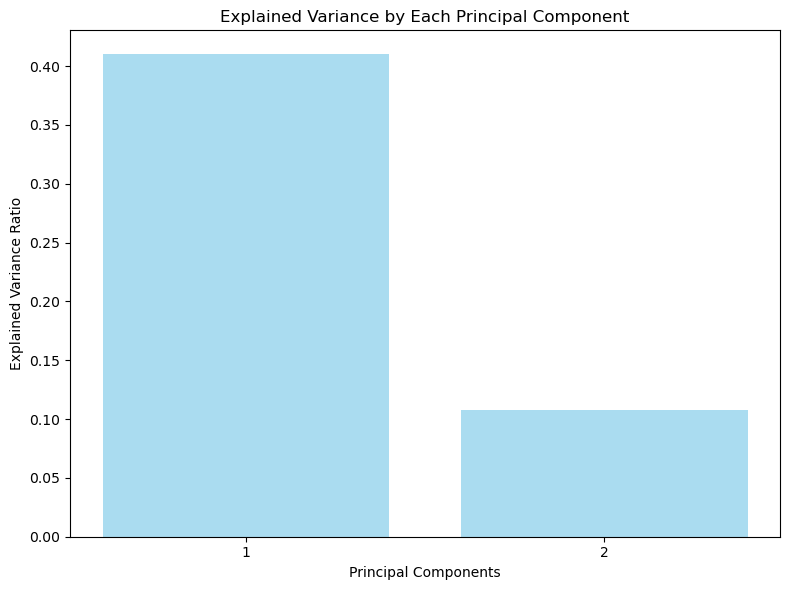

In [21]:
# Lấy tỷ lệ phương sai giải thích
explained_variance = pca.explained_variance_ratio_

# Vẽ biểu đồ tỷ lệ phương sai giải thích
plt.figure(figsize=(8, 6))
plt.bar(np.arange(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='skyblue')

# Thiết lập nhãn trục và tiêu đề
plt.title('Explained Variance by Each Principal Component')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, len(explained_variance) + 1))

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

Phân tích biểu đồ:
Trục X (Principal Components):

Trục X biểu thị các thành phần chính (PC1, PC2, ...). Trong biểu đồ này, chúng ta chỉ có hai thành phần chính: PC1 và PC2.

Trục Y (Explained Variance Ratio):

Trục Y thể hiện tỷ lệ phương sai giải thích, nghĩa là tỷ lệ mà mỗi thành phần chính đóng góp vào sự biến đổi của dữ liệu. Các giá trị dao động từ 0 đến 1, trong đó giá trị gần 1 cho thấy thành phần đó giải thích phần lớn sự biến đổi trong dữ liệu.

Nhận xét về biểu đồ:

PC1 (Principal Component 1): Thành phần chính đầu tiên giải thích một tỷ lệ rất lớn của phương sai trong dữ liệu, chiếm khoảng 0.40 (hoặc 40%). Điều này cho thấy rằng PC1 là thành phần quan trọng nhất và có ảnh hưởng lớn nhất trong việc giảm chiều dữ liệu.

PC2 (Principal Component 2): Thành phần chính thứ hai giải thích một tỷ lệ nhỏ hơn nhiều, chỉ khoảng 0.10 (hoặc 10%). Điều này có nghĩa là PC2 có ít ảnh hưởng hơn PC1 trong việc giải thích sự biến đổi của dữ liệu.

Tầm quan trọng của PCA:

PCA giúp giảm số chiều dữ liệu bằng cách giữ lại các thành phần chính có sự biến đổi lớn nhất, trong khi loại bỏ những thành phần ít quan trọng hơn.

Biểu đồ này chỉ ra rằng chỉ PC1 đã chiếm ưu thế trong việc giải thích phần lớn sự biến thiên của dữ liệu, còn PC2 chỉ đóng góp một phần rất nhỏ.

Tình trạng dữ liệu:

Biểu đồ này cho thấy có thể có sự không đồng đều trong dữ liệu, khi phần lớn sự biến thiên có thể được mô tả bởi một thành phần chính duy nhất (PC1).

Điều này thường gặp khi dữ liệu có sự tương quan mạnh giữa các biến, nghĩa là một phần lớn thông tin có thể được mô tả bằng một vài thành phần chính.

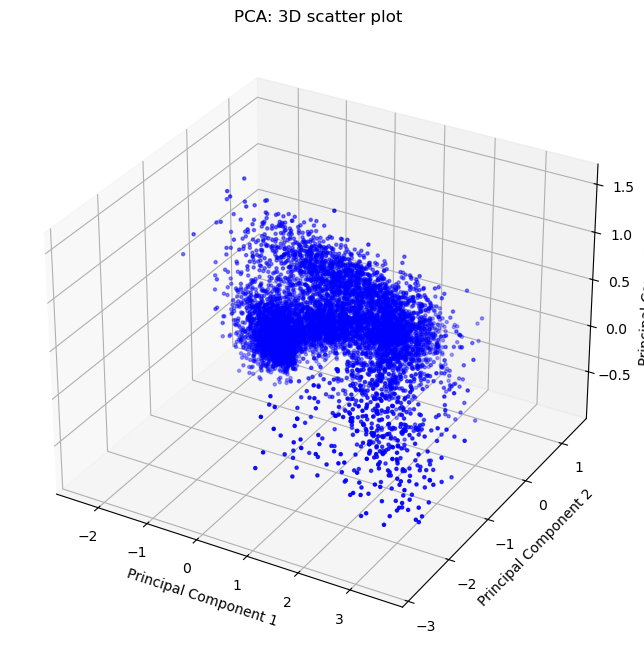

In [12]:
from mpl_toolkits.mplot3d import Axes3D

# Áp dụng PCA để giảm chiều xuống còn 3
pca = PCA(n_components=3)
pca_result_3d = pca.fit_transform(x_train)

# Tạo DataFrame với kết quả PCA
pca_df_3d = pd.DataFrame(data=pca_result_3d, columns=['PC1', 'PC2', 'PC3'])

# Vẽ biểu đồ scatter 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df_3d['PC1'], pca_df_3d['PC2'], pca_df_3d['PC3'], color='blue', s=5)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('PCA: 3D scatter plot')
plt.show()


In [23]:
df_test = pd.read_csv("../data_test_frequency.csv")
df_test.drop(columns=["Unnamed: 0"],inplace=True)
df_test

,0,1,2,3,4,5,6,7,8,9,...,203,204,205,206,207,208,209,210,211,212
0,0.0,14.0,710.769231,628.0,153.204817,556.0,0.996355,0.207174,459.037295,1.000000,...,0.928571,-10.000000,10.0,9.0,146.000000,729.000000,78.250000,3140.437500,127.600000,1041.440000
1,0.0,10.0,968.666667,894.0,266.399867,932.0,0.979352,0.388359,398.464564,1.000000,...,0.600000,64.000000,7.0,7.0,140.500000,15314.750000,-27.000000,5249.000000,112.285714,8081.632653
2,0.0,11.0,797.000000,780.0,251.329664,794.0,0.260470,-1.002325,340.802438,1.000000,...,1.000000,26.000000,9.0,7.0,154.285714,1944.489796,18.571429,8070.530612,131.111111,1078.320988
3,2.0,13.0,757.500000,755.0,8.986100,26.0,0.048579,-1.449012,412.324324,1.000000,...,1.000000,-4.000000,12.0,12.0,108.500000,6122.750000,46.500000,7081.416667,121.833333,264.305556
4,0.0,23.0,413.909091,409.0,82.344017,426.0,3.023659,10.404884,168.041577,0.956522,...,0.083333,0.022262,11.0,12.0,0.044242,0.044242,-50.000000,0.000000,45.818182,832.330579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,1.0,9.0,1071.250000,1062.0,36.509417,118.0,1.263183,0.543003,364.303573,0.888889,...,0.777778,0.000000,9.0,8.0,342.857143,2843.265306,205.142857,11207.836735,96.000000,2281.142857
2126,1.0,8.0,1196.000000,1202.0,33.839959,102.0,-0.454057,-1.036905,181.876516,1.000000,...,1.000000,-26.000000,8.0,7.0,137.666667,228.555556,87.714286,14282.775510,169.142857,46.693878
2127,3.0,16.0,595.600000,590.0,23.734082,82.0,0.371174,-0.657132,137.696567,1.000000,...,1.000000,-8.000000,16.0,14.0,102.714286,1270.061224,7.285714,361.489796,90.400000,2186.240000
2128,1.0,8.0,1080.285714,996.0,180.470587,448.0,0.587475,-1.363827,561.988537,1.000000,...,1.000000,18.000000,8.0,5.0,62.400000,51.840000,-45.200000,0.960000,101.000000,5002.000000


In [24]:
x_test = df_test.iloc[:,1:].values
y_test = df_test.iloc[:,0].values

In [25]:
x_test = scale.transform(x_test)

In [26]:
x_test = pca.transform(x_test)

In [27]:
from sklearn.model_selection import GridSearchCV
model = LogisticRegression()
# params = {
#     'penalty': ['l1', 'l2'],
#     'C': [0.001, 0.01, 0.1],
#     'solver': ['lbfgs', 'liblinear', 'sag', 'saga'],
#     'max_iter': [1,2,3,4],
#     'multi_class': ['auto', 'ovr', 'multinomial'],
#     'n_jobs':[-1],
#     'tol':[0.0001,0.001,0.01]
# }
# {'C': 0.1,
#  'max_iter': 4,
#  'multi_class': 'auto',
#  'n_jobs': -1,
#  'penalty': 'l2',
#  'solver': 'saga',
#  'tol': 0.01}
# 0.915
# params = {
#     'penalty': ['l1', 'l2'],
#     'C': [0.05, 0.1,0.15],
#     'solver': ['lbfgs', 'liblinear', 'sag', 'saga'],
#     'max_iter': [4,6,10],
#     'multi_class': ['auto', 'ovr', 'multinomial'],
#     'n_jobs':[-1],
#     'tol':[0.001,0.01,0.015]
# }
# {'C': 0.15,
#  'max_iter': 10,
#  'multi_class': 'auto',
#  'n_jobs': -1,
#  'penalty': 'l2',
#  'solver': 'sag',
#  'tol': 0.001}
# 0.916
params = {
    'penalty': ['l1', 'l2'],
    'C': [0.12,0.14,0.15],
    'solver': ['lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [6,10,20,30],
    'multi_class': ['auto'],
    'n_jobs':[-1],
    'tol':[0.001,0.01,0.015]
}
# {'C': 0.15,
#  'max_iter': 10,
#  'multi_class': 'auto',
#  'n_jobs': -1,
#  'penalty': 'l2',
#  'solver': 'sag',
#  'tol': 0.001}
# 0.918
# params = {
#     'penalty': ['l1', 'l2'],
#     'C': [0.14,0.15,0.17,0.18],
#     'solver': ['lbfgs', 'liblinear', 'sag', 'saga'],
#     'max_iter': [8,10,15,17],
#     'multi_class': ['auto'],
#     'n_jobs':[-1],
#     'tol':[0.001,0.01,0.015]
# }
grid_search = GridSearchCV(estimator=model, param_grid=params, cv=3, verbose=5, return_train_score=True,refit=True)
grid_model = grid_search.fit(x_train,y_train)

Fitting 3 folds for each of 288 candidates, totalling 864 fits
[CV 1/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=lbfgs, tol=0.001;, score=(train=nan, test=nan) total time=   0.0s
[CV 2/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=lbfgs, tol=0.001;, score=(train=nan, test=nan) total time=   0.0s
[CV 3/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=lbfgs, tol=0.001;, score=(train=nan, test=nan) total time=   0.0s
[CV 1/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=lbfgs, tol=0.01;, score=(train=nan, test=nan) total time=   0.0s
[CV 2/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=lbfgs, tol=0.01;, score=(train=nan, test=nan) total time=   0.0s
[CV 3/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=lbfgs, tol=0.01;, score=(train=nan, test=nan) total time=   0.0s
[CV 1/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=

c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this

[CV 2/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=liblinear, tol=0.001;, score=(train=0.887, test=0.889) total time=   0.0s
[CV 3/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=liblinear, tol=0.001;, score=(train=0.891, test=0.878) total time=   0.0s


c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logist

[CV 1/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=liblinear, tol=0.01;, score=(train=0.885, test=0.894) total time=   0.0s
[CV 2/3] END C=0.12, max_iter=6, multi_class=auto, n_jobs=-1, penalty=l1, solver=liblinear, tol=0.01;, score=(train=0.887, test=0.886) total time=   0.0s


...

c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV 2/3] END C=0.15, max_iter=30, multi_class=auto, n_jobs=-1, penalty=l2, solver=saga, tol=0.015;, score=(train=0.920, test=0.923) total time=   0.2s


c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV 3/3] END C=0.15, max_iter=30, multi_class=auto, n_jobs=-1, penalty=l2, solver=saga, tol=0.015;, score=(train=0.928, test=0.907) total time=   0.2s


c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
216 fits failed out of a total of 864.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
108 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Admin\anaconda3\envs\testdatasets\lib\site-packages\sklearn\linear_model\_logistic.py", line 11

In [28]:
result_test = grid_model.predict(x_test)
result_train = grid_model.predict_proba(x_train)

In [29]:
# pd.DataFrame(result_train).to_csv("./Result/proba_lr.csv")

In [30]:
grid_model.best_params_

{'C': 0.15,
 'max_iter': 20,
 'multi_class': 'auto',
 'n_jobs': -1,
 'penalty': 'l2',
 'solver': 'sag',
 'tol': 0.01}

In [31]:
grid_model.best_score_

0.9178008448550812

In [32]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,multilabel_confusion_matrix,f1_score,precision_score,accuracy_score,recall_score,precision_recall_fscore_support
def evaluation_test(y,y_pred):
    cm = confusion_matrix(y,y_pred)
    disp = ConfusionMatrixDisplay(cm,display_labels=['AFIB','SB','SR','GSVT'])
    disp.plot()
    plt.show()
    n_classes = len(cm)
    class_counts = np.sum(cm, axis=1)
    result = []
    specificities = []
    weights = class_counts / np.sum(class_counts) 
    for c in range(n_classes):
        tp = cm[c,c]
        fp = sum(cm[:,c]) - cm[c,c]
        fn = sum(cm[c,:]) - cm[c,c]
        tn = sum(np.delete(sum(cm)-cm[c,:],c))
        acc = (tp+tn) / (tp+fn+tn+fp)
        recall = tp/(tp+fn)
        precision = tp/(tp+fp)
        specificity = tn/(tn+fp)
        specificities.append(specificity)
        f1_score = 2*((precision*recall)/(precision+recall))
        if c+1 == 1:
            Rhythm = 'AFIB'
        elif c+1 == 2:
            Rhythm = 'SB'
        elif c+1 == 3:
            Rhythm = 'SR'
        else:
            Rhythm = 'GSVT'
        result.append([Rhythm,acc,recall,precision,f1_score,specificity])
    p_macro,r_macro,f_macro,support_macro = precision_recall_fscore_support(y,y_pred,average='macro')
    p_micro,r_micro,f_micro,support_micro = precision_recall_fscore_support(y,y_pred,average='micro')
    p_weighted,r_weighted,f_weighted,support_weighted = precision_recall_fscore_support(y,y_pred,average='weighted')

    s_marco = np.mean(specificities)
    tn_total = np.sum([np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1)) for i in range(n_classes)])
    fp_total = np.sum([np.sum(cm[:, i]) - cm[i, i] for i in range(n_classes)])
    s_mirco = tn_total / (tn_total + fp_total)
    s_weighted = np.sum(weights * specificities)

    result.append(['macro avg',None,f_macro,p_macro,r_macro,s_marco])
    result.append(['micro avg',None,f_micro,p_micro,r_micro,s_mirco])
    result.append(['weighted avg',None,f_weighted,p_weighted,r_weighted,s_weighted])
    return result
        

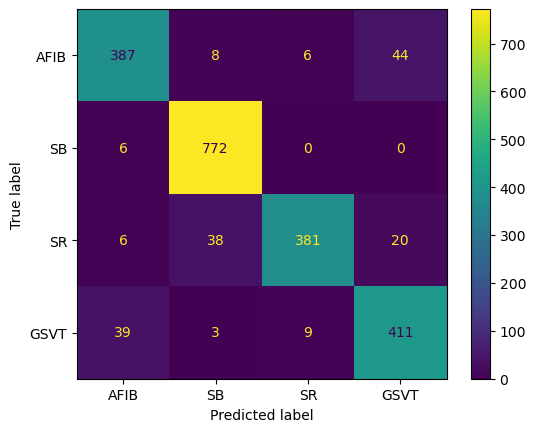

,Rhythm Group,ACC,F1-score,Precision,Recall,specificity
0,AFIB,0.948826,0.869663,0.883562,0.876557,0.969733
1,SB,0.974178,0.992288,0.940317,0.965604,0.963757
2,SR,0.962911,0.856180,0.962121,0.906064,0.991098
3,GSVT,0.946009,0.889610,0.865263,0.877268,0.961631
4,macro avg,NaN,0.906373,0.912816,0.901935,0.971555
5,micro avg,NaN,0.915962,0.915962,0.915962,0.971987
6,weighted avg,NaN,0.915401,0.916736,0.915962,0.970257


In [33]:
evaluation_test = evaluation_test(y_test,result_test)
df_evaluation_test = pd.DataFrame(data=evaluation_test,columns=["Rhythm Group","ACC","F1-score","Precision","Recall","specificity"])
df_evaluation_test

In [34]:
df_evaluation_test.to_csv("./Result/LR_0_99.csv")